#  Performance study: NSR vs. V magnitude

### Setup notebook

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

### Imports

In [29]:
import numpy as np
import pandas as pd
import matplotlib.ticker as mticker

# PlatoSim
import platosim.plot            as pt
import platosim.utilities       as ut
import platosim.referenceFrames as rf
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

## Download data from FTP

In [72]:
# User parameters
idir  = "/lhome/nicholas/data/platosimPaper/NSR"
cfile = idir + "/starcat_all_SPF_CamVis24_NewCat_targets.ftr"

## Test example of how the NSR is calculated

In [73]:
# Load light curve object for the first star only and unpack the data
lcs = LightCurve(f"{idir}/000000001", mode="multi")
lcs.unpack()

In [74]:
# Fetch all files
filenames = lcs.files("hdf5")
filenames

['/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam1.1_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam1.2_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam1.3_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam1.4_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam1.5_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam1.6_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam2.1_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam2.2_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam2.3_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam2.4_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam2.5_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam2.6_Q1.hdf5']

In [76]:
# Merge all N-CAM light curves
lc, ncam, flag = lcs.merge(quarter=1, flux_group_mean=True, suffix='hdf5')

In [78]:
# Calculate the NSR in 1h
lc.getNSR(influx='ppm')

55.91647864908076

<IPython.core.display.Javascript object>


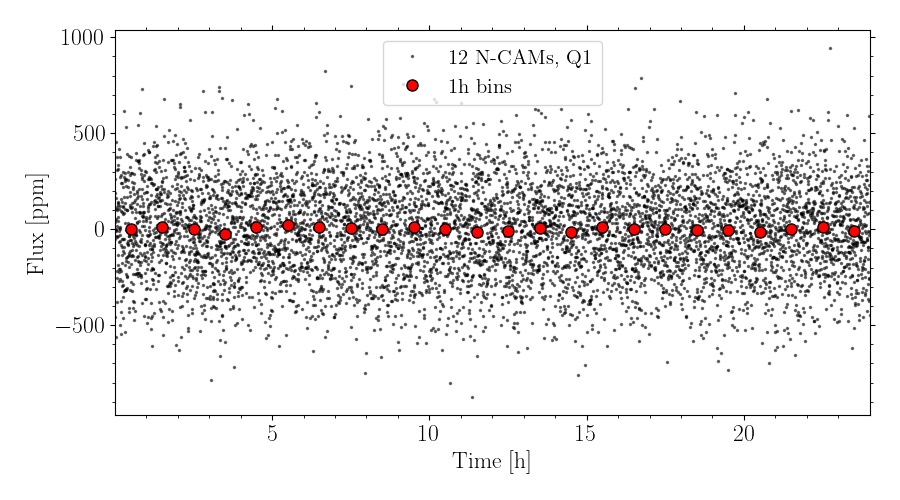

In [79]:
# Show plot to verify result
lc.plot(time_unit="h", flux_unit='ppm', ncam=ncam, quarter=1, binsize=1, alpha=0.5, figsize=(9,5));

## Analysis of Merged N-CAM LCs

In [95]:
ofile = idir + "/results_per_star.ftr"

In [80]:
# lcs = LightCurve(idir, mode="multi")
# lcs.run_NSRvsMag_analysis_perStar(ofile, 10000, suffix="hdf5")

In [96]:
# Load results and sort logically
df = pd.read_feather(ofile)
df

,index,star,quarter,ncam,NSR,flag
0,0,1,1,12,55.916477,0
1,0,2,1,18,50.737873,0
2,0,3,1,12,41.747032,0
3,0,4,1,12,80.457657,0
4,0,5,1,6,50.640957,0
...,...,...,...,...,...,...
9475,0,9996,1,6,39.156902,0
9476,0,9997,1,6,146.576584,0
9477,0,9998,1,6,171.291107,0
9478,0,9999,1,6,70.956795,0


In [97]:
# Load input catalogue
dc = pd.read_feather(cfile)
N = len(dc)

# Merge the two data frames
mag  = np.array([])
ncon = np.array([])
for i in range(N):
    nobs = len(df[df.star == i+1])    
    mags = dc.mag.iloc[i] * np.ones(nobs)
    mag  = np.concatenate((mag, mags))
    ncons = dc.ncon.iloc[i] * np.ones(nobs)
    ncon  = np.concatenate((ncon, ncons))                
df["mag"]  = mag
df["ncon"] = ncon
df

,index,star,quarter,ncam,NSR,flag,mag,ncon
0,0,1,1,12,55.916477,0,10.618521,1.0
1,0,2,1,18,50.737873,0,10.768657,0.0
2,0,3,1,12,41.747032,0,10.060707,0.0
3,0,4,1,12,80.457657,0,11.282410,0.0
4,0,5,1,6,50.640957,0,9.783687,0.0
...,...,...,...,...,...,...,...,...
9475,0,9996,1,6,39.156902,0,9.182682,0.0
9476,0,9997,1,6,146.576584,0,11.718769,2.0
9477,0,9998,1,6,171.291107,0,12.070425,1.0
9478,0,9999,1,6,70.956795,0,10.369341,1.0


In [98]:
df['mag'] = mag[:len(df)]

In [99]:
# dx[dx.star == 1000]
df

,index,star,quarter,ncam,NSR,flag,mag,ncon
0,0,1,1,12,55.916477,0,10.618521,1.0
1,0,2,1,18,50.737873,0,10.768657,0.0
2,0,3,1,12,41.747032,0,10.060707,0.0
3,0,4,1,12,80.457657,0,11.282410,0.0
4,0,5,1,6,50.640957,0,9.783687,0.0
...,...,...,...,...,...,...,...,...
9475,0,9996,1,6,39.156902,0,9.182682,0.0
9476,0,9997,1,6,146.576584,0,11.718769,2.0
9477,0,9998,1,6,171.291107,0,12.070425,1.0
9478,0,9999,1,6,70.956795,0,10.369341,1.0


<IPython.core.display.Javascript object>


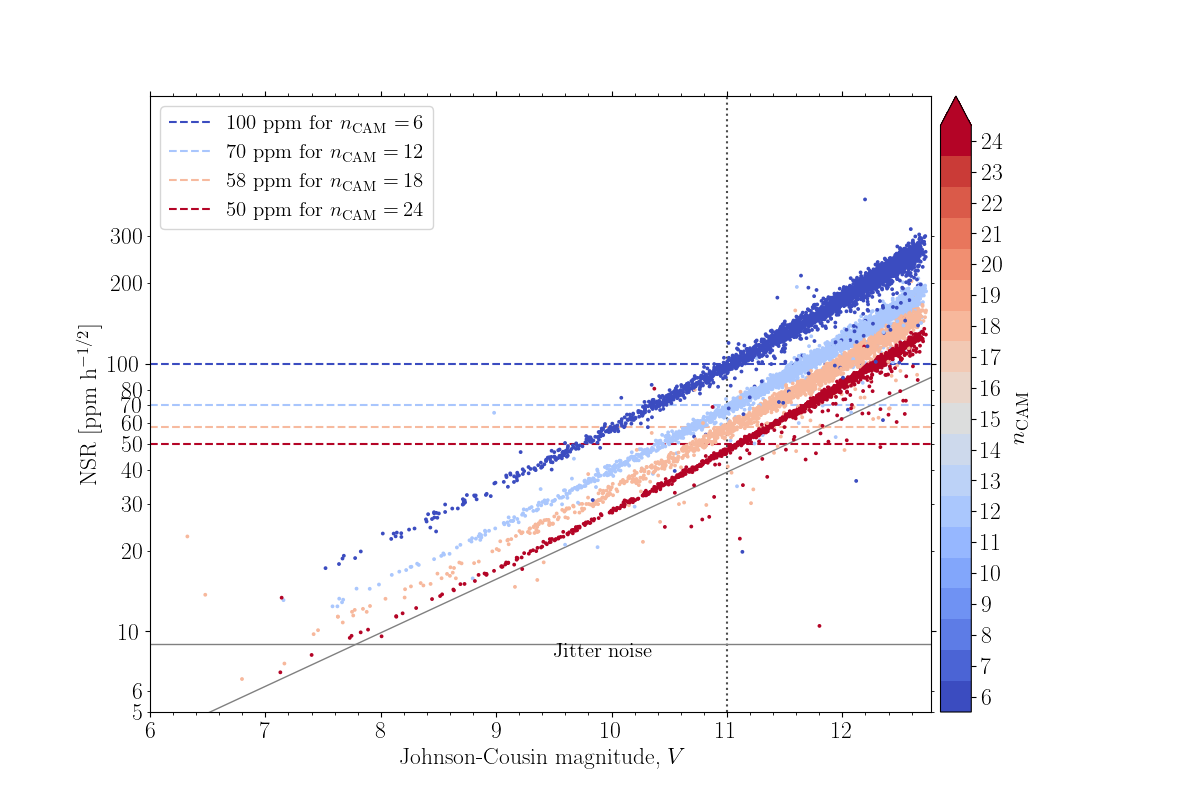

/tmp/ipykernel_1298419/3555663867.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ticks_minor)


In [141]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, column="ncam", Vmag=True, residuals="multi", 
                                legend=True, grid=False, figsize=(12,8)) #(9,8))

# Set axes limits
ax.set_xlim(6, 12.77)
ax.set_ylim(5, 1000) #340)

# We change the fontsize of minor ticks label 
ticks_minor = [5, 6, 20, 30, 40, 50, 60, 70, 80, 200, 300]
ax.yaxis.set_minor_locator(mticker.FixedLocator(ticks_minor))
ax.set_yticklabels(ticks_minor)
ticks_major = [1, 10, 100]
ax.yaxis.set_major_locator(mticker.FixedLocator(ticks_major))
ax.set_yticklabels(ticks_major)

# Save figure
fig.savefig('NSRvsV.png', bbox_inches='tight', dpi=300);

## Analysis of Indiviual N-CAM LCs

In [87]:
ofile = idir + "/results_per_camera.ftr"

In [163]:
# lcs = LightCurve(idir, mode="multi")
# lcs.run_NSRvsMag_analysis_perCamera(ofile, 10000, suffix="hdf5")

In [88]:
# Load results and sort logically
df = pd.read_feather(ofile)
df

,index,star,group,camera,quarter,mag,NSR
0,0,1,1,2,1,NaN,192.932632
1,0,1,1,3,1,NaN,194.348206
2,0,1,1,4,1,NaN,187.786850
3,0,1,1,5,1,NaN,191.740433
4,0,1,1,6,1,NaN,192.872070
...,...,...,...,...,...,...,...
122467,0,10000,3,2,1,NaN,173.179581
122468,0,10000,3,3,1,NaN,175.303558
122469,0,10000,3,4,1,NaN,170.157883
122470,0,10000,3,5,1,NaN,171.576889


In [89]:
# Load input catalogue
dc = pd.read_feather(cfile)
N = len(dc)

# Merge the two data frames
mag  = np.array([])
ncon = np.array([])
for i in range(N):
    nobs = len(df[df.star == i+1])    
    mags = dc.mag.iloc[i] * np.ones(nobs)
    mag  = np.concatenate((mag, mags))
    ncons = dc.ncon.iloc[i] * np.ones(nobs)
    ncon  = np.concatenate((ncon, ncons))                
df["mag"]  = mag
df["ncon"] = ncon
df

,index,star,group,camera,quarter,mag,NSR,ncon
0,0,1,1,2,1,10.618521,192.932632,1.0
1,0,1,1,3,1,10.618521,194.348206,1.0
2,0,1,1,4,1,10.618521,187.786850,1.0
3,0,1,1,5,1,10.618521,191.740433,1.0
4,0,1,1,6,1,10.618521,192.872070,1.0
...,...,...,...,...,...,...,...,...
122467,0,10000,3,2,1,10.352194,173.179581,0.0
122468,0,10000,3,3,1,10.352194,175.303558,0.0
122469,0,10000,3,4,1,10.352194,170.157883,0.0
122470,0,10000,3,5,1,10.352194,171.576889,0.0


In [52]:
mag = df.mag.unique()
mag

array([10.61852143, 10.76865675, 10.0607073 , ..., 12.07042534,
       10.36934093, 10.35219421])

<IPython.core.display.Javascript object>


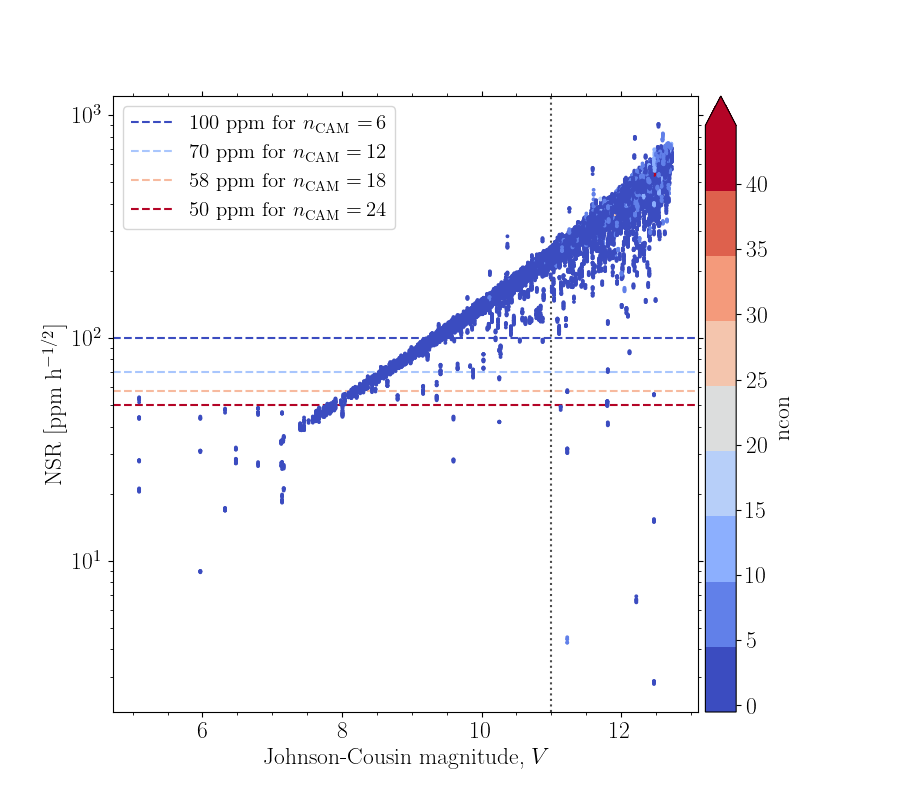

In [92]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, column="ncon", Vmag=True, residuals="multi", 
                                legend=True, grid=False, figsize=(9,8))

# Set axes limits
# ax.set_xlim(7, 12.77)
# ax.set_ylim(6, 340)

#### From average of N-CAMs

In [35]:
dx = pd.DataFrame()
for i in range(1, 10001):
    star = df.loc[df["star"] == i]
    ncam = len(star)
    if ncam > 0:
        mag  = star.mag.iloc[0]
        nsr  = star.NSR.mean() / np.sqrt(ncam)
        data = {'star':i, "mag":mag, "ncam":ncam, "NSR":nsr}
        dx = dx.append(data, ignore_index=True)

/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ver

/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ver

/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ver

/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ver

/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ver

...

/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ver

/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ver

/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ver

/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ver

/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dx = dx.append(data, ignore_index=True)
/tmp/ipykernel_1298419/4121147120.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ver

In [36]:
dx

,star,mag,ncam,NSR
0,1.0,10.618521,11.0,57.520549
1,2.0,10.768657,17.0,49.378519
2,3.0,10.060707,11.0,43.633213
3,4.0,11.282410,11.0,84.072566
4,5.0,9.783687,5.0,55.779677
...,...,...,...,...
9475,9996.0,9.182682,5.0,43.139765
9476,9997.0,11.718769,5.0,159.632052
9477,9998.0,12.070425,5.0,184.664781
9478,9999.0,10.369341,5.0,78.814825


<IPython.core.display.Javascript object>


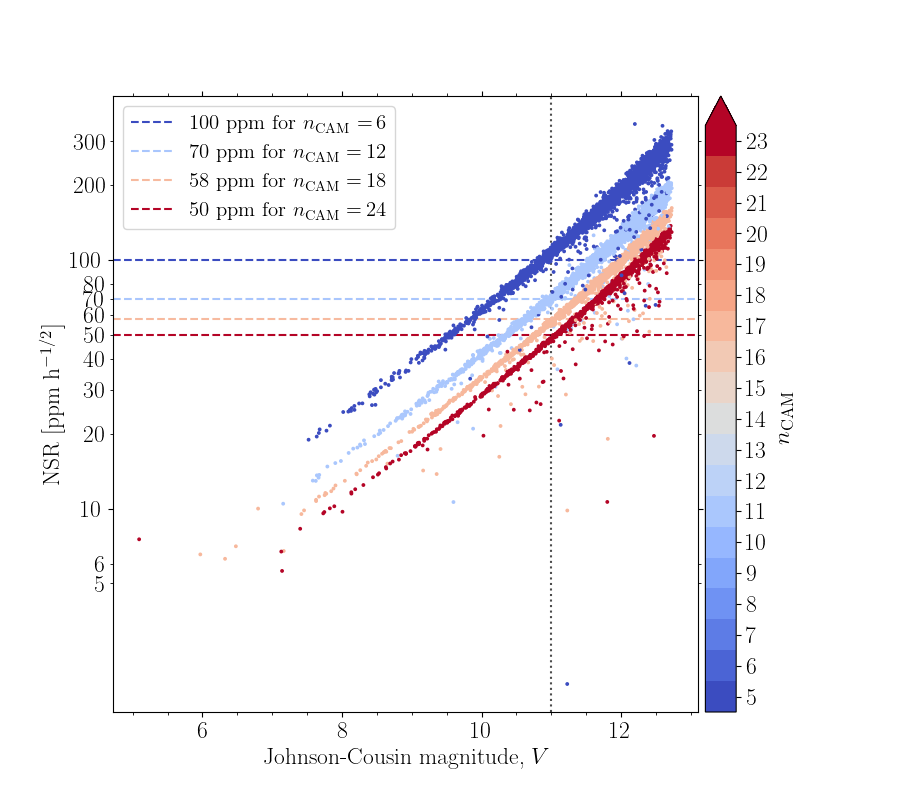

/tmp/ipykernel_1298419/2473351410.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ticks_minor)


In [37]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(dx, column="ncam", Vmag=True, residuals="multi", 
                                legend=True, grid=False, figsize=(9,8))

# Set axes limits
# ax.set_xlim(7, 12.77)
# ax.set_ylim(6, 340)

# We change the fontsize of minor ticks label 
ticks_minor = [5, 6, 20, 30, 40, 50, 60, 70, 80, 200, 300]
ax.yaxis.set_minor_locator(mticker.FixedLocator(ticks_minor))
ax.set_yticklabels(ticks_minor)
ticks_major = [1, 10, 100]
ax.yaxis.set_major_locator(mticker.FixedLocator(ticks_major))
ax.set_yticklabels(ticks_major);

# Save figure
# fig.savefig('NSRvsV.png', bbox_inches='tight', dpi=300);